# Análisis de reseñas de Trustpilot

## Objetivo

El objetivo de este proyecto es analizar las reseñas de una empresa del dataset de Trustpilot utilizando técnicas de NLP para:

- Evaluar el sentimiento de los clientes
- Identificar los principales temas (topics) en las reseñas
- Analizar el sentimiento asociado a cada tema
- Detectar fortalezas y áreas de mejora

La empresa seleccionada es **Airtime Rewards**, perteneciente al sector de Money & Insurance.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga de datos

Se cargan los datasets proporcionados:
- Reseñas de Trustpilot
- Empresas con 100 reviews

Se selecciona una empresa concreta para el análisis.

In [5]:
df = pd.read_csv("../data/raw/trustpilot-reviews-123k.csv")
empresas = pd.read_excel("../data/raw/emp_100_reviews.xlsx")

In [6]:
print(df.shape)
print(empresas.shape)

df.head()

(123181, 6)
(558, 6)


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


In [7]:
print(df.columns.tolist())
print(empresas.columns.tolist())

['category', 'company', 'description', 'title', 'review', 'stars']
['category', 'company', 'n_reviews', 'median_stars', 'media_stars', 'std_stars']


In [8]:
empresas.head(20)

,category,company,n_reviews,median_stars,media_stars,std_stars
0,Animals & Pets,gardenbird.co.uk,100,3,3,1.421338
1,Restaurants & Bars,www.brewersfayre.co.uk,100,3,3,1.421338
2,Restaurants & Bars,mindfulchef.com,100,3,3,1.421338
3,Restaurants & Bars,nonnatonda.co.uk,100,3,3,1.421338
4,Restaurants & Bars,planthood.co.uk,100,3,3,1.421338
5,Restaurants & Bars,simplycook.com,100,3,3,1.421338
6,Restaurants & Bars,thecornishfishmonger.co.uk,100,3,3,1.421338
7,Restaurants & Bars,wetherspoons.co.uk,100,3,3,1.421338
8,Restaurants & Bars,www.burgerking.co.uk,100,3,3,1.421338
9,Restaurants & Bars,www.oddbox.co.uk,100,3,3,1.421338


In [9]:
conteo_reviews = (
    df[df["company"].isin(empresas["company"])]
    .groupby("company")
    .size()
    .reset_index(name="n_reviews_csv")
    .sort_values("n_reviews_csv", ascending=False)
)

conteo_reviews.head(20)

,company,n_reviews_csv
0,1stchoice.co.uk,100
1,360.optimalegal.co.uk,100
2,airtimerewards.co.uk,100
3,allbeauty.com,100
4,amawaste.co.uk,100
5,anchorpumps.com,100
6,anyjunk.co.uk,100
7,arbolus.com,100
8,ariston.com,100
9,ascenti.co.uk,100


## Exploración de datos

Se analiza la distribución de reseñas y se selecciona una empresa con:

- Distribución equilibrada de estrellas
- Variedad de opiniones
- Sector con potencial analítico

In [10]:
stats_empresas = (
    df[df["company"].isin(empresas["company"])]
    .groupby("company")
    .agg(
        n_reviews=("stars", "count"),
        media_stars=("stars", "mean"),
        std_stars=("stars", "std"),
        min_stars=("stars", "min"),
        max_stars=("stars", "max")
    )
    .reset_index()
    .sort_values(["std_stars", "n_reviews"], ascending=[False, False])
)

stats_empresas.head(20)

,company,n_reviews,media_stars,std_stars,min_stars,max_stars
0,1stchoice.co.uk,100,3.0,1.421338,1,5
1,360.optimalegal.co.uk,100,3.0,1.421338,1,5
2,airtimerewards.co.uk,100,3.0,1.421338,1,5
3,allbeauty.com,100,3.0,1.421338,1,5
4,amawaste.co.uk,100,3.0,1.421338,1,5
5,anchorpumps.com,100,3.0,1.421338,1,5
6,anyjunk.co.uk,100,3.0,1.421338,1,5
7,arbolus.com,100,3.0,1.421338,1,5
8,ariston.com,100,3.0,1.421338,1,5
9,ascenti.co.uk,100,3.0,1.421338,1,5


In [11]:
sector_empresa = (
    df[["company", "category"]]
    .drop_duplicates()
)

candidatas = stats_empresas.merge(sector_empresa, on="company", how="left")
candidatas.head(20)

,company,n_reviews,media_stars,std_stars,min_stars,max_stars,category
0,1stchoice.co.uk,100,3.0,1.421338,1,5,Vehicles & Transportation
1,360.optimalegal.co.uk,100,3.0,1.421338,1,5,Legal Services & Government
2,airtimerewards.co.uk,100,3.0,1.421338,1,5,Money & Insurance
3,allbeauty.com,100,3.0,1.421338,1,5,Beauty & Well-being
4,amawaste.co.uk,100,3.0,1.421338,1,5,Home Services
5,anchorpumps.com,100,3.0,1.421338,1,5,Construction & Manufacturing
6,anyjunk.co.uk,100,3.0,1.421338,1,5,Public & Local Services
7,arbolus.com,100,3.0,1.421338,1,5,Public & Local Services
8,ariston.com,100,3.0,1.421338,1,5,Construction & Manufacturing
9,ascenti.co.uk,100,3.0,1.421338,1,5,Health & Medical


In [12]:
top_candidatas = candidatas.head(10)["company"].tolist()

for empresa in top_candidatas:
    print(f"\nEmpresa: {empresa}")
    print(df[df["company"] == empresa]["stars"].value_counts().sort_index())


Empresa: 1stchoice.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: 360.optimalegal.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: airtimerewards.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: allbeauty.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: amawaste.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: anchorpumps.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: anyjunk.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: arbolus.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: ariston.com
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

Empresa: ascenti.co.uk
stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64


In [13]:
df_empresa = df[df["company"] == "airtimerewards.co.uk"]

df_empresa["stars"].value_counts().sort_index()

stars
1    20
2    20
3    20
4    20
5    20
Name: count, dtype: int64

In [14]:
df_empresa["review"].head(5)

58565    Easy to make a purchase and get airtime credit...
58566    100% recommend to anyone it saves a fortune of...
58567    Like it as no effort to earn money.done need t...
58568    A wonderful platform. It allows me to earn cas...
58569    Great way to benefit from everyday spending an...
Name: review, dtype: object

## Selección de la empresa analizada

La empresa seleccionada para el análisis es **Airtime Rewards**, perteneciente al sector **Money & Insurance**.

La elección se justifica por tres motivos principales:

- Presenta una variedad de temas adecuada para aplicar técnicas de NLP.
- Su actividad está relacionada con recompensas, transacciones y experiencia de usuario, lo que permite obtener insights de negocio relevantes.
- Facilita una comparación interesante con otras empresas del mismo sector financiero incluidas en el dataset.

## Preprocesamiento de texto

Se realiza limpieza del texto para preparar los datos para el análisis:

- Conversión a minúsculas
- Eliminación de caracteres especiales
- Eliminación de stopwords
- Lematización

Este paso es clave para mejorar la calidad de los modelos NLP.

In [15]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    palabras = texto.split()
    palabras = [w for w in palabras if w not in stop_words]
    palabras = [lemmatizer.lemmatize(w) for w in palabras]
    return " ".join(palabras)

df_empresa = df[df["company"] == "airtimerewards.co.uk"].copy()

df_empresa.loc[:, "clean_review"] = df_empresa["review"].apply(limpiar_texto)
df_empresa.loc[:, "sentimiento"] = df_empresa["stars"].apply(
    lambda x: "positivo" if x >= 4 else "negativo"
)

print(df_empresa["clean_review"].isna().sum())
df_empresa[["review", "clean_review", "sentimiento"]].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pepetorres\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pepetorres\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


0


,review,clean_review,sentimiento
58565,Easy to make a purchase and get airtime credit...,easy make purchase get airtime credit account ...,positivo
58566,100% recommend to anyone it saves a fortune of...,recommend anyone save fortune phone bill save ...,positivo
58567,Like it as no effort to earn money.done need t...,like effort earn money done need activate offe...,positivo
58568,A wonderful platform. It allows me to earn cas...,wonderful platform allows earn cashbacks purch...,positivo
58569,Great way to benefit from everyday spending an...,great way benefit everyday spending save money...,positivo


## Análisis de sentimiento

Se clasifica cada reseña como positiva o negativa en función de la puntuación (stars).

Resultados:
- 60% de las reseñas son negativas
- 40% son positivas

Esto indica una percepción general negativa de la empresa, aunque con cierta polarización.

In [16]:
df_empresa["sentimiento"].value_counts(normalize=True)

sentimiento
negativo    0.6
positivo    0.4
Name: proportion, dtype: float64

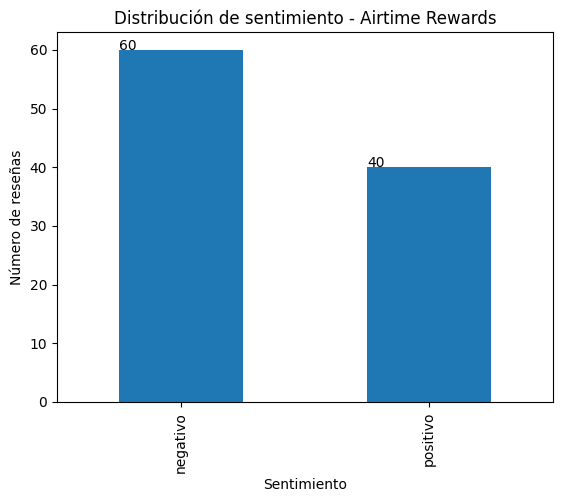

In [17]:
ax = df_empresa["sentimiento"].value_counts().plot(kind="bar")
plt.title("Distribución de sentimiento - Airtime Rewards")
plt.xlabel("Sentimiento")
plt.ylabel("Número de reseñas")

for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x(), p.get_height()))

plt.show()

In [18]:
df_empresa["clean_review"].isna().sum()

np.int64(0)

In [19]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(max_df=0.9, min_df=5)
X = vectorizer.fit_transform(df_empresa["clean_review"])

In [20]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [21]:
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i}:")
    print([words[i] for i in topic.argsort()[-10:]])


Topic 0:
['account', 'work', 'card', 'purchase', 'one', 'reward', 'get', 'credit', 'airtime', 'transaction']

Topic 1:
['use', 'phone', 'day', 'great', 'missing', 'get', 'bill', 'time', 'easy', 'transaction']

Topic 2:
['app', 'list', 'month', 'money', 'waitrose', 'boot', 'shop', 'back', 'reward', 'retailer']

Topic 3:
['spend', 'back', 'take', 'worth', 'bill', 'saved', 'day', 'month', 'reward', 'money']

Topic 4:
['card', 'service', 'customer', 'redeem', 'app', 'account', 'phone', 'bill', 'airtime', 'reward']


## Análisis de topics

Se aplica LDA para identificar los principales temas en las reseñas.

Se identifican los siguientes topics:

- Topic 0: Pagos y recompensas
- Topic 1: Uso del servicio y facturación
- Topic 2: Compras y partners
- Topic 3: Valor y ahorro
- Topic 4: Atención al cliente

In [22]:
topic_values = lda.transform(X)
df_empresa["topic"] = topic_values.argmax(axis=1)

## Relación entre topics y sentimiento

Se analiza el sentimiento asociado a cada tema.

Principales resultados:

- Pagos y recompensas: mayoritariamente negativo (~81%)
- Valor y ahorro: mayoritariamente negativo (~80%)
- Compras y partners: negativo (~70%)
- Uso del servicio: mixto (50/50)
- Atención al cliente: ligeramente positivo (~51%)

Esto permite identificar los principales problemas del servicio.

In [23]:
pd.crosstab(df_empresa["topic"], df_empresa["sentimiento"], normalize="index")

sentimiento,negativo,positivo
topic,,
0,0.812500,0.187500
1,0.500000,0.500000
2,0.700000,0.300000
3,0.800000,0.200000
4,0.487179,0.512821


## Modelado de temas avanzado (BERTopic)

Con el objetivo de validar los resultados obtenidos mediante LDA, se aplica BERTopic, un modelo basado en embeddings que permite identificar temas de forma más contextual.

Los resultados obtenidos son consistentes con los temas previamente identificados, reforzando la robustez del análisis.

In [24]:
from bertopic import BERTopic

# usar textos limpios
docs = df_empresa["clean_review"].tolist()

topic_model = BERTopic(language="english")
topics, probs = topic_model.fit_transform(docs)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6134.81it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [25]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18,-1_time_reward_use_month,"[time, reward, use, month, app, many, withdraw...",[ok suppose money nothing personally use many ...
1,0,44,0_airtime_reward_transaction_account,"[airtime, reward, transaction, account, credit...",[airtime reward used fantastic way save phone ...
2,1,38,1_bill_reward_money_phone,"[bill, reward, money, phone, retailer, great, ...",[joined day ago time joining checked retailer ...


In [26]:
topic_model.get_topic(0)

[('airtime', np.float64(0.09088510155387132)),
 ('reward', np.float64(0.05722628772630869)),
 ('transaction', np.float64(0.053508690778940535)),
 ('account', np.float64(0.047241346596358744)),
 ('credit', np.float64(0.04392296675532767)),
 ('card', np.float64(0.042742170730038866)),
 ('get', np.float64(0.03448731164877869)),
 ('time', np.float64(0.03315187050997694)),
 ('bill', np.float64(0.03162909485405039)),
 ('work', np.float64(0.02992021517664129))]

In [28]:
for topic_id in topic_model.get_topic_info()["Topic"].head(10):
    if topic_id != -1:
        print(f"\nTopic {topic_id}:")
        print(topic_model.get_topic(topic_id))


Topic 0:
[('airtime', np.float64(0.09088510155387132)), ('reward', np.float64(0.05722628772630869)), ('transaction', np.float64(0.053508690778940535)), ('account', np.float64(0.047241346596358744)), ('credit', np.float64(0.04392296675532767)), ('card', np.float64(0.042742170730038866)), ('get', np.float64(0.03448731164877869)), ('time', np.float64(0.03315187050997694)), ('bill', np.float64(0.03162909485405039)), ('work', np.float64(0.02992021517664129))]

Topic 1:
[('bill', np.float64(0.08893816047758818)), ('reward', np.float64(0.08413864413558872)), ('money', np.float64(0.07058692804224352)), ('phone', np.float64(0.0693777226344639)), ('retailer', np.float64(0.06267651055454498)), ('great', np.float64(0.061103279656673004)), ('good', np.float64(0.04824519944618888)), ('would', np.float64(0.04472696649656428)), ('app', np.float64(0.0441932175192809)), ('get', np.float64(0.043100092522240736))]


In [38]:
topic_info = topic_model.get_topic_info()
topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,18,-1_time_reward_use_month,"[time, reward, use, month, app, many, withdraw...",[ok suppose money nothing personally use many ...
1,0,44,0_airtime_reward_transaction_account,"[airtime, reward, transaction, account, credit...",[airtime reward used fantastic way save phone ...
2,1,38,1_bill_reward_money_phone,"[bill, reward, money, phone, retailer, great, ...",[joined day ago time joining checked retailer ...


## Validación de topics con BERTopic

Se ha aplicado BERTopic como técnica avanzada de modelado de temas basada en embeddings, con el objetivo de validar los resultados obtenidos previamente mediante LDA.

Los resultados muestran la existencia de dos grandes bloques temáticos:

- Un primer grupo centrado en el uso del servicio, incluyendo aspectos como transacciones, cuentas y funcionamiento general.
- Un segundo grupo enfocado en el beneficio económico percibido por el usuario, destacando conceptos como recompensas, ahorro y facturación.

Ambos coinciden con los temas identificados previamente mediante LDA, lo que refuerza la consistencia del análisis.

El modelo también identifica un pequeño conjunto de documentos no agrupados (outliers), lo cual es habitual en este tipo de técnicas y no afecta a la interpretación global.

In [39]:
import networkx as nx
from collections import Counter
import itertools

# tokenizar (usa tus clean_review)
docs = df_empresa["clean_review"].str.split()

# pares de palabras por documento (limitando a top frecuentes)
all_words = Counter(itertools.chain.from_iterable(docs))
vocab = set([w for w, _ in all_words.most_common(100)])

edges = Counter()
for tokens in docs:
    tokens = [w for w in tokens if w in vocab]
    pairs = set(itertools.combinations(tokens, 2))
    for p in pairs:
        edges[p] += 1

G = nx.Graph()
for (u, v), w in edges.items():
    if w >= 5:  # umbral
        G.add_edge(u, v, weight=w)

# nodos más importantes
centralidad = nx.degree_centrality(G)
top_nodos = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
top_nodos

[('reward', 0.7333333333333333),
 ('bill', 0.45),
 ('airtime', 0.4),
 ('get', 0.31666666666666665),
 ('card', 0.31666666666666665),
 ('retailer', 0.3),
 ('great', 0.2833333333333333),
 ('time', 0.25),
 ('phone', 0.23333333333333334),
 ('month', 0.21666666666666667)]

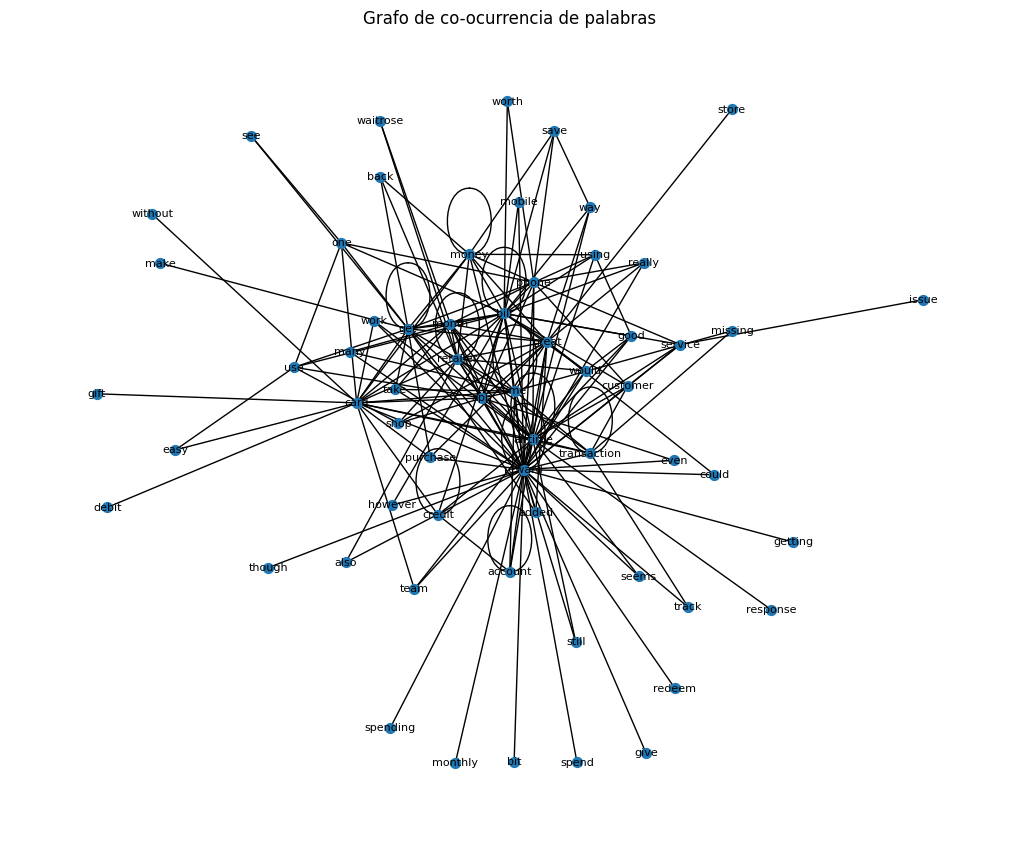

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=50, font_size=8)
plt.title("Grafo de co-ocurrencia de palabras")
plt.show()

## Análisis mediante grafos

Se construye un grafo de co-ocurrencia de palabras para identificar las relaciones entre los principales conceptos presentes en las reseñas.

Los nodos con mayor centralidad representan los términos más relevantes en la experiencia del usuario.

Los resultados muestran que el término **"reward"** es el nodo más central, lo que indica que la percepción del servicio está fuertemente ligada al sistema de recompensas.

Otros términos relevantes como **"bill"**, **"card"** y **"retailer"** sugieren que los problemas están relacionados con transacciones, pagos y la interacción con partners comerciales.

Este análisis refuerza los resultados obtenidos previamente, confirmando que las principales incidencias se encuentran en el núcleo del producto, especialmente en la obtención y gestión del cashback.

## Conclusiones Airtime Rewards

Los principales problemas de la empresa se encuentran en:

- Fallos en el sistema de recompensas
- Baja percepción de valor por parte del cliente
- Problemas en la interacción con partners comerciales

Como punto positivo, la atención al cliente presenta mejores resultados.

Se recomienda:

- Mejorar la fiabilidad del sistema de cashback
- Alinear expectativas del cliente con la realidad del servicio
- Optimizar la relación con retailers

## Análisis de la competencia

En este apartado se analizan varias empresas del mismo sector que Airtime Rewards.

Debido a que el dataset presenta una distribución uniforme de estrellas, la comparación de sentimiento global no es representativa.

Por ello, el análisis se centra en identificar los principales temas (topics) en las reseñas de la competencia y compararlos con los de Airtime Rewards.

In [41]:
# Obtener sector
sector = df_empresa["category"].iloc[0]

# Filtrar sector
df_sector = df[df["category"] == sector].copy()

# Selección de competidores
competidores = [
    "www.cashback.co.uk",
    "smallworldfs.com",
    "www.unbiased.co.uk"
]

df_comp = df_sector[df_sector["company"].isin(competidores)].copy()

df_comp["company"].value_counts()

company
smallworldfs.com      100
www.cashback.co.uk    100
www.unbiased.co.uk    100
Name: count, dtype: int64

In [42]:
df_comp.loc[:, "clean_review"] = df_comp["review"].apply(limpiar_texto)

df_comp[["review", "clean_review"]].head()

,review,clean_review
54524,Interacting with the App is user friendly. It ...,interacting app user friendly appears security...
54525,Have been sending money with Small world for o...,sending money small world year ups sending tra...
54526,I started using the service in 2016. My experi...,started using service experience good customer...
54527,I recently made a transaction to send money to...,recently made transaction send money philippin...
54528,"Services good and fast, trust they have. I lat...",service good fast trust later discovered earli...


In [43]:
df_comp.loc[:, "sentimiento"] = df_comp["stars"].apply(
    lambda x: "positivo" if x >= 4 else "negativo"
)

In [44]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer_comp = CountVectorizer(max_df=0.9, min_df=5)
X_comp = vectorizer_comp.fit_transform(df_comp["clean_review"])

lda_comp = LatentDirichletAllocation(n_components=5, random_state=42)
lda_comp.fit(X_comp)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [45]:
words_comp = vectorizer_comp.get_feature_names_out()

for i, topic in enumerate(lda_comp.components_):
    print(f"\nTopic {i}:")
    print([words_comp[i] for i in topic.argsort()[-10:]])


Topic 0:
['easy', 'gambling', 'completed', 'free', 'cashback', 'money', 'level', 'time', 'site', 'task']

Topic 1:
['sent', 'app', 'send', 'transaction', 'rate', 'small', 'world', 'transfer', 'service', 'money']

Topic 2:
['month', 'like', 'task', 'make', 'service', 'call', 'one', 'get', 'money', 'time']

Topic 3:
['detail', 'choose', 'offer', 'see', 'would', 'adviser', 'get', 'money', 'like', 'good']

Topic 4:
['would', 'company', 'looking', 'one', 'financial', 'pension', 'advice', 'find', 'unbiased', 'advisor']


## Topics en la competencia

A partir del análisis de las reseñas de las empresas competidoras mediante LDA, se identifican los siguientes temas principales:

- **Topic 0: Gamificación y obtención de recompensas**  
  Relacionado con la realización de tareas y la obtención de cashback o recompensas, donde los usuarios valoran la facilidad para ganar dinero o beneficios.

- **Topic 1: Transferencias y operaciones financieras**  
  Asociado al envío de dinero, transacciones y tasas aplicadas, reflejando la experiencia en operaciones financieras básicas.

- **Topic 2: Uso del servicio y experiencia general**  
  Incluye aspectos relacionados con la interacción con el servicio, tiempos de uso y experiencia global del usuario.

- **Topic 3: Ofertas y recomendaciones**  
  Centrado en la percepción de ofertas, recomendaciones y valoraciones positivas del servicio o productos financieros.

- **Topic 4: Asesoramiento financiero**  
  Relacionado con servicios de asesoramiento, planificación financiera y toma de decisiones en productos como pensiones o inversiones.

En conjunto, los topics identificados reflejan una experiencia más diversificada en la competencia, abarcando tanto operaciones financieras como servicios de asesoramiento y propuestas de valor más amplias.

In [46]:
df_empresa_comp = df_empresa.copy()
df_empresa_comp.loc[:, "company"] = "Airtime Rewards"

df_total = pd.concat([df_empresa_comp, df_comp], ignore_index=True)

Empresas analizadas:
['Airtime Rewards', 'smallworldfs.com', 'www.cashback.co.uk', 'www.unbiased.co.uk']

Número de documentos: 4

Matriz de similitud:


,Airtime Rewards,smallworldfs.com,www.cashback.co.uk,www.unbiased.co.uk
Airtime Rewards,1.000000,0.333601,0.262294,0.177856
smallworldfs.com,0.333601,1.000000,0.310500,0.229183
www.cashback.co.uk,0.262294,0.310500,1.000000,0.195147
www.unbiased.co.uk,0.177856,0.229183,0.195147,1.000000



Aristas creadas:
[('Airtime Rewards', 'smallworldfs.com', {'weight': np.float64(0.3336005801879005)}), ('Airtime Rewards', 'www.cashback.co.uk', {'weight': np.float64(0.2622940236122782)}), ('Airtime Rewards', 'www.unbiased.co.uk', {'weight': np.float64(0.17785568727660694)}), ('smallworldfs.com', 'www.cashback.co.uk', {'weight': np.float64(0.31049960461585524)}), ('smallworldfs.com', 'www.unbiased.co.uk', {'weight': np.float64(0.22918266054365044)}), ('www.cashback.co.uk', 'www.unbiased.co.uk', {'weight': np.float64(0.19514664440731438)})]


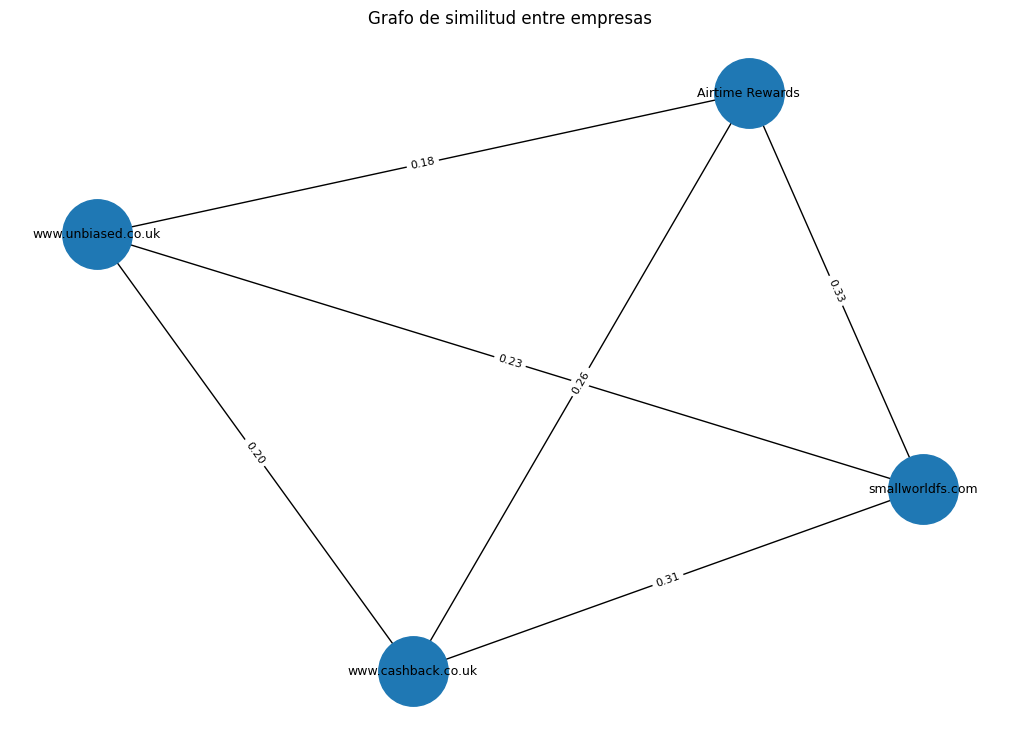

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Agrupar todas las reseñas limpias por empresa
df_group = df_total.groupby("company")["clean_review"].apply(lambda x: " ".join(x))

print("Empresas analizadas:")
print(df_group.index.tolist())
print("\nNúmero de documentos:", len(df_group))

# 2. TF-IDF
tfidf = TfidfVectorizer(max_df=1.0, min_df=1)
X = tfidf.fit_transform(df_group)

# 3. Matriz de similitud
sim = cosine_similarity(X)

empresas = df_group.index.tolist()
sim_df = pd.DataFrame(sim, index=empresas, columns=empresas)

print("\nMatriz de similitud:")
display(sim_df)

# 4. Crear grafo SIN umbral inicial
G_emp = nx.Graph()

for empresa in empresas:
    G_emp.add_node(empresa)

for i in range(len(empresas)):
    for j in range(i + 1, len(empresas)):
        G_emp.add_edge(empresas[i], empresas[j], weight=sim[i, j])

print("\nAristas creadas:")
print(list(G_emp.edges(data=True)))

# 5. Visualización
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_emp, seed=42)

nx.draw(
    G_emp,
    pos,
    with_labels=True,
    node_size=2500,
    font_size=9
)

edge_labels = {
    (u, v): f"{d['weight']:.2f}" for u, v, d in G_emp.edges(data=True)
}
nx.draw_networkx_edge_labels(G_emp, pos, edge_labels=edge_labels, font_size=8)

plt.title("Grafo de similitud entre empresas")
plt.show()

## Grafo de similitud entre empresas

Se construye un grafo de similitud entre empresas a partir de la representación TF-IDF de sus reseñas.

Los resultados muestran que Airtime Rewards presenta mayor similitud con smallworldfs.com, lo que indica que ambas empresas comparten patrones de conversación similares en las reseñas de los usuarios, especialmente en torno a transacciones y operaciones financieras.

Por otro lado, la similitud con www.cashback.co.uk es moderada, lo que sugiere una coincidencia parcial en la propuesta de valor basada en recompensas.

Finalmente, www.unbiased.co.uk presenta una baja similitud, lo que indica que su enfoque, centrado en asesoramiento financiero, difiere significativamente del resto.

Este análisis permite identificar qué competidores son realmente comparables desde la perspectiva del cliente, aportando una visión más precisa del posicionamiento de Airtime Rewards en el mercado.

## Comparación con Airtime Rewards

El análisis comparativo entre Airtime Rewards y sus competidores revela diferencias significativas en los temas predominantes de las reseñas.

En el caso de Airtime Rewards, los principales topics identificados están relacionados con:

- Problemas en el sistema de recompensas (cashback)
- Fallos en transacciones y acreditación de beneficios
- Baja percepción de valor por parte del usuario

Estos aspectos afectan directamente al núcleo del producto, es decir, a la propuesta de valor principal de la empresa.

Por otro lado, la competencia presenta una mayor diversidad de temas, incluyendo:

- Operaciones financieras como transferencias de dinero
- Experiencia general de uso del servicio
- Ofertas y recomendaciones
- Servicios de asesoramiento financiero

En este caso, los problemas identificados están más relacionados con aspectos operativos o de experiencia, y no tanto con fallos estructurales del producto.

Esto sugiere que, mientras la competencia enfrenta retos asociados al uso del servicio, Airtime Rewards presenta debilidades más críticas que impactan directamente en su propuesta de valor.

## Limitaciones del análisis

Este análisis presenta algunas limitaciones que conviene tener en cuenta:

- El dataset contiene un máximo de 100 reseñas por empresa.
- La distribución de estrellas está balanceada en las empresas analizadas, por lo que la comparación de sentimiento global entre compañías no resulta especialmente informativa.
- El sentimiento se aproxima a partir de la variable `stars`, lo que simplifica la interpretación emocional real del texto.
- Los topics obtenidos mediante LDA requieren una interpretación analítica, por lo que pueden existir matices no capturados completamente por el modelo.

Aun con estas limitaciones, el análisis permite identificar patrones útiles sobre la experiencia del cliente y áreas de mejora.

## Conclusiones finales

El análisis de las reseñas de Airtime Rewards mediante técnicas de NLP pone de manifiesto una percepción general negativa por parte de los usuarios, con aproximadamente un 60% de opiniones desfavorables.

El modelado de temas (LDA) permite identificar tres grandes áreas de fricción:

- Problemas en el funcionamiento del sistema de recompensas
- Incidencias en la fiabilidad de las transacciones
- Baja percepción del valor real del servicio

Estos resultados se han validado mediante técnicas adicionales, incluyendo análisis estructural con grafos y modelado avanzado con BERTopic, obteniendo patrones temáticos consistentes en todos los enfoques. Esto refuerza la robustez del análisis y confirma que los problemas detectados responden a patrones reales en las opiniones de los usuarios.

En la comparación con la competencia, se observa que Airtime Rewards presenta problemas de carácter más estructural, mientras que otras empresas del sector concentran sus incidencias en aspectos más puntuales relacionados con la experiencia de uso.

A partir de estos resultados, se proponen las siguientes líneas de actuación:

- Mejorar la fiabilidad del sistema de cashback
- Garantizar la correcta ejecución de las transacciones
- Reforzar la propuesta de valor percibida por el usuario
- Optimizar la gestión de partners y acuerdos comerciales

En conjunto, este análisis permite identificar áreas críticas de mejora y posicionar a la empresa frente a sus competidores desde una perspectiva basada en datos y validada mediante múltiples enfoques analíticos.